In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("dataset/mmash_for_interpolation_test.csv")

In [6]:
df

,time,x,y,z,heart_rate,sleep_stage,steps,user_id,hr_weighted_avg
0,-24483.449456,0.121704,-0.440369,-0.890656,NaN,NaN,0.0,4018081,NaN
1,-24483.431540,0.120666,-0.436951,-0.888733,NaN,NaN,0.0,4018081,NaN
2,-24483.411333,0.116714,-0.439392,-0.885895,NaN,NaN,0.0,4018081,NaN
3,-24483.391450,0.118652,-0.438400,-0.885376,NaN,NaN,0.0,4018081,NaN
4,-24483.371426,0.118744,-0.436951,-0.889740,NaN,NaN,0.0,4018081,NaN
...,...,...,...,...,...,...,...,...,...
51819146,28828.068306,0.509995,0.462479,-0.559250,NaN,-1.0,0.0,844359,NaN
51819147,28828.089226,0.465301,0.612167,-0.612411,NaN,-1.0,0.0,844359,NaN
51819148,28828.109608,0.429871,0.622650,-0.694794,NaN,-1.0,0.0,844359,NaN
51819149,28828.128373,0.506653,0.607361,-0.815720,NaN,-1.0,0.0,844359,NaN


In [5]:
# Weighted Moving Average
def weighted_moving_average(series, window=5):
    weights = np.arange(1, window + 1)
    return series.rolling(window).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)

df['hr_weighted_avg'] = df['heart_rate'].rolling(window=10, center=True).mean()


In [7]:
try:
    # For very large datasets like yours (51M rows), spline might be slow.
    # We limit the limit_direction to fill all gaps.
    df['hr_spline'] = df['heart_rate'].interpolate(method='cubic')
except Exception as e:
    print(f"Cubic spline error (likely memory or index): {e}")
    df['hr_spline'] = df['hr_linear'] # Fallback


In [11]:
df['hr_linear'] = df['heart_rate'].interpolate(method='linear')

In [8]:
df.head(-40)

,time,x,y,z,heart_rate,sleep_stage,steps,user_id,hr_weighted_avg,hr_spline
0,-24483.449456,0.121704,-0.440369,-0.890656,NaN,NaN,0.0,4018081,NaN,NaN
1,-24483.431540,0.120666,-0.436951,-0.888733,NaN,NaN,0.0,4018081,NaN,NaN
2,-24483.411333,0.116714,-0.439392,-0.885895,NaN,NaN,0.0,4018081,NaN,NaN
3,-24483.391450,0.118652,-0.438400,-0.885376,NaN,NaN,0.0,4018081,NaN,NaN
4,-24483.371426,0.118744,-0.436951,-0.889740,NaN,NaN,0.0,4018081,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
51819106,28827.665691,0.483185,0.329269,-0.709747,NaN,-1.0,0.0,844359,NaN,NaN
51819107,28827.666143,0.563980,0.383194,-0.679535,NaN,-1.0,0.0,844359,NaN,NaN
51819108,28827.666528,0.616867,0.432632,-0.669815,NaN,-1.0,0.0,844359,NaN,NaN
51819109,28827.666904,0.607163,0.441879,-0.673431,NaN,-1.0,0.0,844359,NaN,NaN


In [12]:
print(df.count())

time               51819151
x                  51819151
y                  51819151
z                  51819151
heart_rate          8173660
sleep_stage        49154572
steps              51819151
user_id            51819151
hr_weighted_avg     6796454
hr_spline          51817430
hr_linear          51818591
dtype: int64


In [ ]:
df.info()

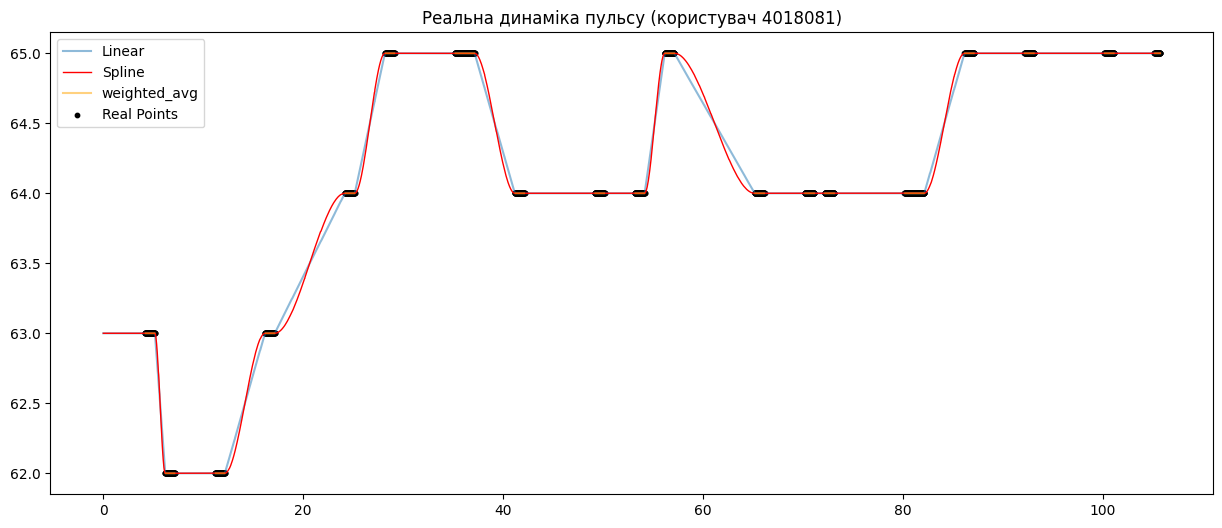

In [13]:
target_user = 4018081
user_data = df[df['user_id'] == target_user]

# 5000 рядків ~2.5 хвилини
sample_size = 7000
start_idx = len(user_data) // 2
user_sample = user_data.iloc[start_idx : start_idx + sample_size].copy()

# Обчислимо відносний час
user_sample['time_rel'] = user_sample['time'] - user_sample['time'].iloc[0]

plt.figure(figsize=(15, 6))
plt.plot(user_sample['time_rel'], user_sample['hr_linear'], label='Linear', alpha=0.5)
plt.plot(user_sample['time_rel'], user_sample['hr_spline'], label='Spline', color='red', linewidth=1)
plt.plot(user_sample['time_rel'], user_sample['hr_weighted_avg'], label='weighted_avg', color='orange', alpha=0.5)
plt.scatter(user_sample['time_rel'], user_sample['heart_rate'], color='black', s=10, label='Real Points')


plt.title(f"Реальна динаміка пульсу (користувач {target_user})")
plt.legend()
plt.show()

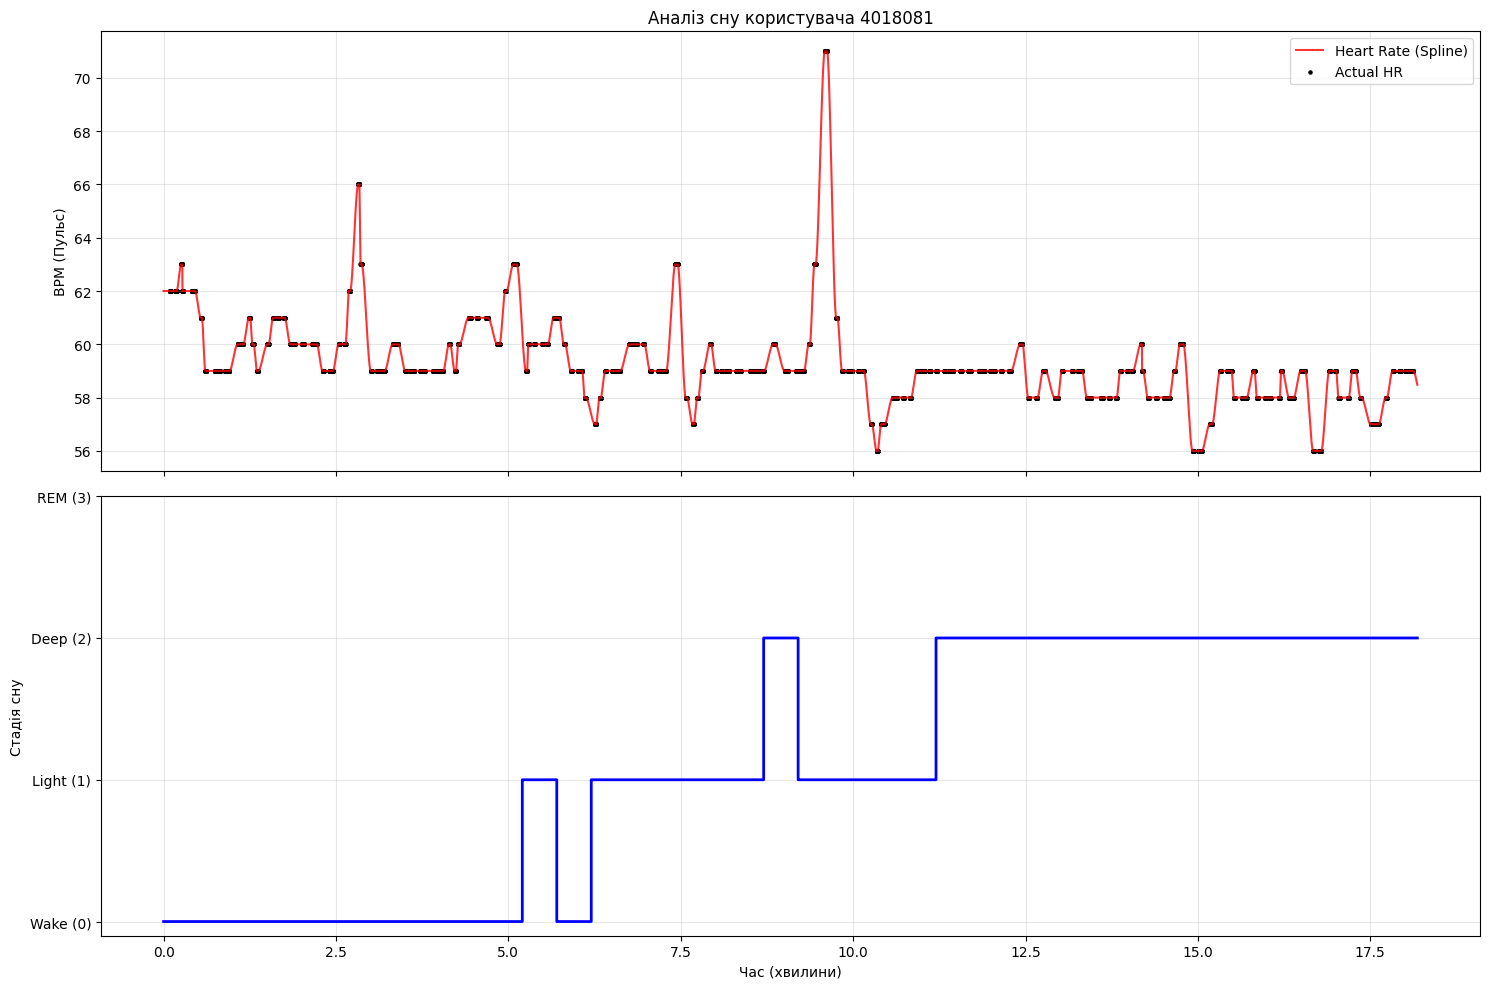

In [20]:
sample_size = 70000
start_idx = 141595
user_sample = df[df['user_id'] == target_user].iloc[start_idx : start_idx + sample_size].copy()

# Відносний час у хвилинах для зручності
user_sample['time_min'] = (user_sample['time'] - user_sample['time'].iloc[0]) / 60

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# --- ГРАФІК ПУЛЬСУ ---
ax1.plot(user_sample['time_min'], user_sample['hr_spline'], color='red', label='Heart Rate (Spline)', alpha=0.8)
ax1.scatter(user_sample['time_min'], user_sample['heart_rate'], color='black', s=5, label='Actual HR')
ax1.set_ylabel('BPM (Пульс)')
ax1.set_title(f'Аналіз сну користувача {target_user}')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- ГРАФІК ФАЗ СНУ ---
# Використовуємо step для відображення "сходинок"
ax2.step(user_sample['time_min'], user_sample['sleep_stage'], where='post', color='blue', linewidth=2, label='Sleep Stage')

# Налаштування осі Y для сну (0-3 або 0-4 залежно від маркування)
ax2.set_yticks([0, 1, 2, 3])
ax2.set_yticklabels(['Wake (0)', 'Light (1)', 'Deep (2)', 'REM (3)']) # Перевір маркування в описі MMASH
ax2.set_ylabel('Стадія сну')
ax2.set_xlabel('Час (хвилини)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()